In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
from rpa_control.paths import save_fig

In [ ]:


# ── Fold-change detector ─────────────────────────────────────────────
# dA/dt = X - A      (A tracks X)
# dB/dt = X/A - B    (B senses X/A; B* = 1 at any X)
def fcd_rhs(t, state, X_of_t):
    A, B = state
    X = X_of_t(t)
    return [X - A, X / A - B]

# Piecewise X: 1 → 2 → 4
t1, t2, t_end = 10.0, 30.0, 45.0
def u_of_t(t):
    if t < t1: return 1.0
    if t < t2: return 2.0
    return 4.0

t = np.linspace(0, t_end, 6000)
A0, B0 = 1.0, 1.0
sol = solve_ivp(fcd_rhs, [0, t_end], [A0, B0], t_eval=t,
                args=(u_of_t,), max_step=0.05, rtol=1e-8, atol=1e-10)
A = sol.y[0]
B = sol.y[1]


# ── Plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(4.5, 3), sharex=True)

# u: 
ax = axes[0]
lw = 2
for segment in [(0, t1), (t1, t2), (t2, t_end)]:
    ax.plot(segment, [u_of_t(segment[0]+0.01), u_of_t(segment[1]-0.01)], lw=lw, color='k')
ax.set_ylabel('u')
ax.set_yticks([2, 4])
ax.set_ylim(bottom=0)

# A:
ax = axes[1]
ax.plot(t, A, lw=lw, color='C1')
ax.set_ylabel('A')
ax.set_yticks([2, 4])

# B:
ax = axes[2]
ax.plot(t, B, lw=lw, color='C0')
ax.set_ylabel('B')
ax.set_xlabel('time')
ax.set_ylim(top=1.35)

for ax in axes:
    sns.despine(ax=ax)

plt.show()


save_fig(fig, 'figure5_A.pdf')


# Panel C

In [ ]:


# ── Fold-change detector ─────────────────────────────────────────────
# dA/dt = X - A      (A tracks X)
# dB/dt = X/A - B    (B senses X/A; B* = 1 at any X)
def fcd_rhs(t, state, X_of_t):
    A, B = state
    X = X_of_t(t)
    return [X - A, X / A - B]

# Piecewise X: 1 → 2 → 4
t1, t2, t_end = 10.0, 30.0, 45.0
def u_of_t_sensitized(t):
    if t < t1: return 2.0
    if t < t2: return 1.0
    return 4.0

t = np.linspace(0, t_end, 6000)
A0, B0 = 2.0, 1.0
sol = solve_ivp(fcd_rhs, [0, t_end], [A0, B0], t_eval=t,
                args=(u_of_t_sensitized,), max_step=0.05, rtol=1e-8, atol=1e-10)
A_sensitized = sol.y[0]
B_sensitized = sol.y[1]


# ── Plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(2, 2), sharex=True)

# u: 
ax = axes[0]
lw = 2
for segment in [(0, t1), (t1, t2), (t2, t_end)]:
    ax.plot(segment, [u_of_t_sensitized(segment[0]+0.01), u_of_t_sensitized(segment[1]-0.01)], lw=lw, color='k')
ax.set_ylabel('u')
ax.set_yticks([2, 4])
ax.set_ylim(bottom=0)

# A:
# ax = axes[1]
# ax.plot(t, A_sensitized, lw=lw, color='C1')
# ax.set_ylabel('A')
# ax.set_yticks([2, 4])

# B:
ax = axes[1]
ax.plot(t, B_sensitized, lw=lw, color='C0')

# mask = t > 30
# ax.plot(t[mask], B[mask], lw=lw, color='C0', zorder=-1, linestyle='--')
ax.set_ylabel('B')
ax.set_xlabel('time')
ax.set_ylim(top=1.7)

for ax in axes:
    sns.despine(ax=ax)

plt.show()


save_fig(fig, 'figure5_C.pdf')


In [ ]:


# Piecewise X: 1 → 2 → 4
t1, t2, t_end = 10.0, 30.0, 45.0




# ── Plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(4, 2), sharex=True, sharey='row')


# standard:
def u_of_t(t):
    if t < t1: return 2.0
    if t < t2: return 2.0
    return 4.0


t = np.linspace(0, t_end, 6000)
A0, B0 = 2.0, 1.0
sol = solve_ivp(fcd_rhs, [0, t_end], [A0, B0], t_eval=t,
                args=(u_of_t,), max_step=0.05, rtol=1e-8, atol=1e-10)
A = sol.y[0]
B = sol.y[1]


# u standard: 
ax = axes[0,0]
lw = 2
for segment in [(0, t1), (t1, t2), (t2, t_end)]:
    ax.plot(segment, [u_of_t(segment[0]+0.01), u_of_t(segment[1]-0.01)], lw=lw, color='k')
ax.set_ylabel('u')
ax.set_yticks([2, 4])
ax.set_ylim(bottom=0)

# B standard:
ax = axes[1,0]
ax.plot(t, B, lw=lw, color='C0')
ax.set_ylabel('B')
ax.set_xlabel('time')
ax.set_ylim(bottom=0.7, top=1.7)



# sensitized:
def u_of_t_sensitized(t):
    if t < t1: return 2.0
    if t < t2: return 1.0
    return 4.0

t = np.linspace(0, t_end, 6000)
A0, B0 = 2.0, 1.0
sol = solve_ivp(fcd_rhs, [0, t_end], [A0, B0], t_eval=t,
                args=(u_of_t_sensitized,), max_step=0.05, rtol=1e-8, atol=1e-10)
A_sensitized = sol.y[0]
B_sensitized = sol.y[1]


# u sensitized: 
ax = axes[0,1]
lw = 2
for segment in [(0, t1), (t1, t2), (t2, t_end)]:
    ax.plot(segment, [u_of_t_sensitized(segment[0]+0.01), u_of_t_sensitized(segment[1]-0.01)], lw=lw, color='k')
ax.set_ylabel('u')
ax.set_yticks([2, 4])
ax.set_ylim(bottom=0)

# B sensitized:
ax = axes[1,1]
ax.plot(t, B_sensitized, lw=lw, color='C0')
ax.set_ylabel('B')
ax.set_xlabel('time')
ax.set_ylim(bottom=0.7, top=1.7)



for ax in axes.flatten():
    sns.despine(ax=ax)

plt.show()


save_fig(fig, 'figure5_C_B.pdf')


In [ ]:
# Sensitized step vs slow ramp from 2 → 1
t1, t2, t_end = 10.0, 30.0, 45.0


# ── Plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(4, 2),
                         sharex=True, sharey='row')

lw = 2

# ── Left: sensitized (abrupt step down then up) ──────────────────────
def u_of_t_sensitized(t):
    if t < t1: return 2.0
    if t < t2: return 1.0
    return 4.0

t = np.linspace(0, t_end, 6000)
A0, B0 = 2.0, 1.0
sol = solve_ivp(fcd_rhs, [0, t_end], [A0, B0], t_eval=t,
                args=(u_of_t_sensitized,), max_step=0.05,
                rtol=1e-8, atol=1e-10)
B_sensitized = sol.y[1]

ax = axes[0, 0]
for segment in [(0, t1), (t1, t2), (t2, t_end)]:
    ax.plot(segment,
            [u_of_t_sensitized(segment[0] + 0.01),
             u_of_t_sensitized(segment[1] - 0.01)],
            lw=lw, color='k')
ax.set_ylabel('u')
ax.set_yticks([2, 4])
ax.set_ylim(bottom=0)

ax = axes[1, 0]
ax.plot(t, B_sensitized, lw=lw, color='C0')
ax.set_ylabel('B')
ax.set_xlabel('time')
ax.set_ylim(bottom=0.7, top=1.7)


# ── Right: ramp from 2 → 1 over [t1, t2], then jump to 4 ────────────
def u_of_t_ramp(t):
    if t < t1: return 2.0
    if t < t2: return 2.0 + (1.0 - 2.0) * (t - t1) / (t2 - t1)
    return 4.0

t = np.linspace(0, t_end, 6000)
A0, B0 = 2.0, 1.0
sol = solve_ivp(fcd_rhs, [0, t_end], [A0, B0], t_eval=t,
                args=(u_of_t_ramp,), max_step=0.05,
                rtol=1e-8, atol=1e-10)
B_ramp = sol.y[1]

ax = axes[0, 1]
u_ramp_vals = np.array([u_of_t_ramp(tt) for tt in t])
u_plot = u_ramp_vals.copy()
u_plot[np.isclose(t, t2, atol=t[1] - t[0])] = np.nan
ax.plot(t, u_plot, lw=lw, color='k')
ax.set_ylabel('u')
ax.set_yticks([2, 4])
ax.set_ylim(bottom=0)

ax = axes[1, 1]
ax.plot(t, B_ramp, lw=lw, color='C0')
ax.set_ylabel('B')
ax.set_xlabel('time')
ax.set_ylim(bottom=0.7, top=1.7)


for ax in axes.flatten():
    sns.despine(ax=ax)

plt.show()

save_fig(fig, 'figure5_C_B_ramp.pdf')


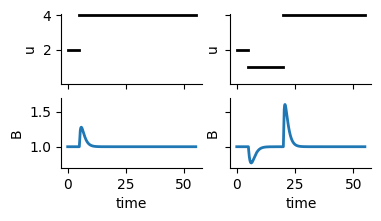

Figure saved to /Users/jonathansomer/repos/autodiff-control/plots/figure5_case_1_direct_vs_sensitized_uB.pdf
1.4595618068704355
Time to progression (direct): 33.89481580263377
Time to progression (sensitized): 49.471578596432735


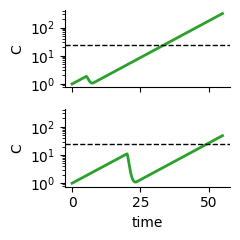

Figure saved to /Users/jonathansomer/repos/autodiff-control/plots/figure5_case_1_direct_vs_sensitized_C.pdf


In [129]:
# Add C dynamics: dC/dt = C * (c1 - c2 * max(B - mu, 0))
t1, t2, t_end = 5.0, 20.0, 55.0
c1, c2, mu = 0.12, 3, 1.1
C0 = 1.0


def integrate_C(t, B):
    def f(tt, C):
        B_t = np.interp(tt, t, B)
        return C[0] * (c1 - c2 * max(B_t - mu, 0.0))
    sol = solve_ivp(f, [t[0], t[-1]], [C0], t_eval=t,
                    max_step=0.05, rtol=1e-8, atol=1e-10)
    return sol.y[0]


# ── Simulate both cases ──────────────────────────────────────────────
def u_of_t_direct(t):
    if t < t1: return 2.0
    return 4.0

def u_of_t_sensitized(t):
    if t < t1: return 2.0
    if t < t2: return 1.0
    return 4.0

t = np.linspace(0, t_end, 6000)
A0, B0 = 2.0, 1.0

sol = solve_ivp(fcd_rhs, [0, t_end], [A0, B0], t_eval=t,
                args=(u_of_t_direct,), max_step=0.05,
                rtol=1e-8, atol=1e-10)
B_direct = sol.y[1]
C_direct = integrate_C(t, B_direct)

sol = solve_ivp(fcd_rhs, [0, t_end], [A0, B0], t_eval=t,
                args=(u_of_t_sensitized,), max_step=0.05,
                rtol=1e-8, atol=1e-10)
B_sensitized = sol.y[1]
C_sensitized = integrate_C(t, B_sensitized)


# ── Figure 1: u and B (2×2) ─────────────────────────────────────────
fig_uB, axes = plt.subplots(nrows=2, ncols=2, figsize=(4, 2),
                            sharex=True, sharey='row')

lw = 2

# Left: direct
ax = axes[0, 0]
for segment in [(0, t1), (t1, t_end)]:
    ax.plot(segment,
            [u_of_t_direct(segment[0] + 0.01),
             u_of_t_direct(segment[1] - 0.01)],
            lw=lw, color='k')
ax.set_ylabel('u')
ax.set_yticks([2, 4])
ax.set_ylim(bottom=0)

ax = axes[1, 0]
ax.plot(t, B_direct, lw=lw, color='C0')
ax.set_ylabel('B')
ax.set_xlabel('time')
ax.set_ylim(bottom=0.7, top=1.7)

# Right: sensitized
ax = axes[0, 1]
for segment in [(0, t1), (t1, t2), (t2, t_end)]:
    ax.plot(segment,
            [u_of_t_sensitized(segment[0] + 0.01),
             u_of_t_sensitized(segment[1] - 0.01)],
            lw=lw, color='k')
ax.set_ylabel('u')
ax.set_yticks([2, 4])
ax.set_ylim(bottom=0)

ax = axes[1, 1]
ax.plot(t, B_sensitized, lw=lw, color='C0')
ax.set_ylabel('B')
ax.set_xlabel('time')
ax.set_ylim(bottom=0.7, top=1.7)

for ax in axes.flatten():
    sns.despine(ax=ax)

plt.show()

save_fig(fig_uB, 'figure5_case_1_direct_vs_sensitized_uB.pdf')


# ── Figure 2: C only (1×2) ──────────────────────────────────────────
fig_C, axes_C = plt.subplots(nrows=2, ncols=1, figsize=(2.5, 2.5),
                             sharex=True, sharey=True)

TTP_THRESHOLD = 25

ax = axes_C[0]
ax.plot(t, C_direct, lw=lw, color='C2')
ax.set_ylabel('C')
ax.set_xlabel('time')
ax.axhline(TTP_THRESHOLD, color='k', linestyle='--', lw=1)
ax.set_yscale('log')

ax = axes_C[1]
ax.plot(t, C_sensitized, lw=lw, color='C2')
ax.set_ylabel('C')
ax.set_xlabel('time')
ax.axhline(TTP_THRESHOLD, color='k', linestyle='--', lw=1)
ax.set_yscale('log')

for ax in axes_C:
    sns.despine(ax=ax)


axes_C[0].set_xlabel('')

plt.tight_layout()

# cancer time to progression
TTP_direct = t[C_direct > TTP_THRESHOLD][0] if any(C_direct > TTP_THRESHOLD) else np.nan
TTP_sensitized = t[C_sensitized > TTP_THRESHOLD][0] if any(C_sensitized > TTP_THRESHOLD) else np.nan
print(TTP_sensitized / TTP_direct)
print(f"Time to progression (direct): {TTP_direct}")
print(f"Time to progression (sensitized): {TTP_sensitized}")

plt.show()

save_fig(fig_C, 'figure5_case_1_direct_vs_sensitized_C.pdf')


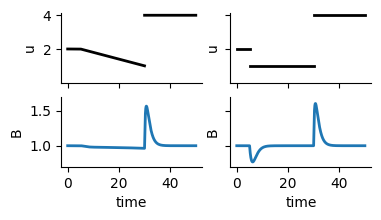

Figure saved to /Users/jonathansomer/repos/autodiff-control/plots/figure5_case_2_ramp_vs_sensitized_uB.pdf
nan
Time to progression (ramp): nan
Time to progression (sensitized): nan


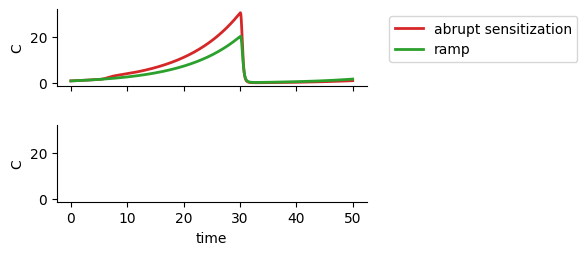

Figure saved to /Users/jonathansomer/repos/autodiff-control/plots/figure5_case_2_ramp_vs_sensitized_C.pdf


In [167]:
# Compare ramp-down vs abrupt sensitization, with dC/dt = C * (c1 - c2 * (B - mu)**3)
t1, t2, t_end = 5.0, 30.0, 50
c1, c2, mu = 0.1, 20, 1
C0 = 1.0


def integrate_C_cubic(t, B):
    def f(tt, C):
        B_t = np.interp(tt, t, B)
        return C[0] * (c1 - c2 * (B_t - mu) ** 3)
    sol = solve_ivp(f, [t[0], t[-1]], [C0], t_eval=t,
                    max_step=0.05, rtol=1e-8, atol=1e-10)
    return sol.y[0]


# ── Inputs ──────────────────────────────────────────────────────────
# Ramp: u stays at 2, ramps linearly 2 → 1 over [t1, t2], then jumps to 4
def u_of_t_ramp(t):
    if t < t1: return 2.0
    if t < t2: return 2.0 + (1.0 - 2.0) * (t - t1) / (t2 - t1)
    return 4.0

# Abrupt sensitization: 2 → 1 → 4
def u_of_t_sensitized(t):
    if t < t1: return 2.0
    if t < t2: return 1.0
    return 4.0


t = np.linspace(0, t_end, 6000)
A0, B0 = 2.0, 1.0

sol = solve_ivp(fcd_rhs, [0, t_end], [A0, B0], t_eval=t,
                args=(u_of_t_ramp,), max_step=0.05,
                rtol=1e-8, atol=1e-10)
B_ramp = sol.y[1]
C_ramp = integrate_C_cubic(t, B_ramp)

sol = solve_ivp(fcd_rhs, [0, t_end], [A0, B0], t_eval=t,
                args=(u_of_t_sensitized,), max_step=0.05,
                rtol=1e-8, atol=1e-10)
B_sensitized = sol.y[1]
C_sensitized = integrate_C_cubic(t, B_sensitized)


# ── Figure 1: u and B (2×2) ─────────────────────────────────────────
fig_uB, axes = plt.subplots(nrows=2, ncols=2, figsize=(4, 2),
                            sharex=True, sharey='row')

lw = 2

# Left: ramp
ax = axes[0, 0]
u_ramp_vals = np.array([u_of_t_ramp(tt) for tt in t])
u_plot = u_ramp_vals.copy()
u_plot[np.isclose(t, t2, atol=t[1] - t[0])] = np.nan
ax.plot(t, u_plot, lw=lw, color='k')
ax.set_ylabel('u')
ax.set_yticks([2, 4])
ax.set_ylim(bottom=0)

ax = axes[1, 0]
ax.plot(t, B_ramp, lw=lw, color='C0')
ax.set_ylabel('B')
ax.set_xlabel('time')
ax.set_ylim(bottom=0.7, top=1.7)

# Right: abrupt sensitization
ax = axes[0, 1]
for segment in [(0, t1), (t1, t2), (t2, t_end)]:
    ax.plot(segment,
            [u_of_t_sensitized(segment[0] + 0.01),
             u_of_t_sensitized(segment[1] - 0.01)],
            lw=lw, color='k')
ax.set_ylabel('u')
ax.set_yticks([2, 4])
ax.set_ylim(bottom=0)

ax = axes[1, 1]
ax.plot(t, B_sensitized, lw=lw, color='C0')
ax.set_ylabel('B')
ax.set_xlabel('time')
ax.set_ylim(bottom=0.7, top=1.7)

for ax in axes.flatten():
    sns.despine(ax=ax)

plt.show()

save_fig(fig_uB, 'figure5_case_2_ramp_vs_sensitized_uB.pdf')


# ── Figure 2: C only (2 rows, stacked) ──────────────────────────────
fig_C, axes_C = plt.subplots(nrows=2, ncols=1, figsize=(4, 2.5),
                             sharex=True, sharey=True, gridspec_kw={'hspace': 0.5})

TTP_THRESHOLD = 1000

ax = axes_C[0]
ax.plot(t, C_sensitized, lw=lw, color='C3', label='abrupt sensitization')
ax.plot(t, C_ramp, lw=lw, color='C2', label='ramp')
ax.set_ylabel('C')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ax = axes_C[1]
# ax.plot(t, C_sensitized, lw=lw, color='C2')
ax.set_ylabel('C')
ax.set_xlabel('time')


for ax in axes_C:
    sns.despine(ax=ax)
    # ax.axhline(TTP_THRESHOLD, color='k', linestyle='--', lw=1)
    # ax.set_yscale('log')

axes_C[0].set_xlabel('')


TTP_ramp = t[C_ramp > TTP_THRESHOLD][0] if any(C_ramp > TTP_THRESHOLD) else np.nan
TTP_sensitized = t[C_sensitized > TTP_THRESHOLD][0] if any(C_sensitized > TTP_THRESHOLD) else np.nan
print(TTP_sensitized / TTP_ramp)
print(f"Time to progression (ramp): {TTP_ramp}")
print(f"Time to progression (sensitized): {TTP_sensitized}")

plt.show()

save_fig(fig_C, 'figure5_case_2_ramp_vs_sensitized_C.pdf')


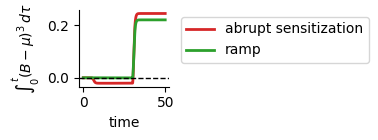

Figure saved to /Users/jonathansomer/repos/autodiff-control/plots/figure5_case_2_ramp_vs_sensitized_integral.pdf


In [168]:
# ── Figure 3: cumulative integral of (B - mu)**3 ────────────────────
from scipy.integrate import cumulative_trapezoid

I_ramp = cumulative_trapezoid((B_ramp - mu) ** 3, t, initial=0.0)
I_sensitized = cumulative_trapezoid((B_sensitized - mu) ** 3, t, initial=0.0)

fig_I, ax = plt.subplots(figsize=(4, 1.5))
ax.plot(t, I_sensitized, lw=lw, color='C3', label='abrupt sensitization')
ax.plot(t, I_ramp,       lw=lw, color='C2', label='ramp')
ax.axhline(0, color='k', linestyle='--', lw=1)
ax.set_xlabel('time')
ax.set_ylabel(r'$\int_0^t (B-\mu)^3\,d\tau$')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

save_fig(fig_I, 'figure5_case_2_ramp_vs_sensitized_integral.pdf')


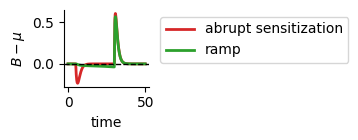

Figure saved to /Users/jonathansomer/repos/autodiff-control/plots/figure5_case_2_ramp_vs_sensitized_B_minus_mu.pdf


In [169]:
# ── Figure 4: B - mu over time ─────────────────────────────────────
fig_Bmu, ax = plt.subplots(figsize=(4, 1.5))
ax.plot(t, B_sensitized - mu, lw=lw, color='C3', label='abrupt sensitization')
ax.plot(t, B_ramp       - mu, lw=lw, color='C2', label='ramp')
ax.axhline(0, color='k', linestyle='--', lw=1)
ax.set_xlabel('time')
ax.set_ylabel(r'$B - \mu$')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

save_fig(fig_Bmu, 'figure5_case_2_ramp_vs_sensitized_B_minus_mu.pdf')


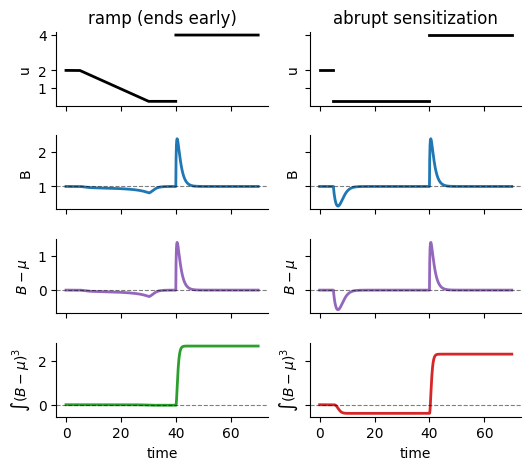

final integral (ramp):       -53.417
final integral (sensitized): -46.051
Figure saved to /Users/jonathansomer/repos/autodiff-control/plots/figure5_case_3_ramp_ends_early.pdf


In [178]:
# Ramp ends before t2 so B re-equilibrates to u=1 before the jump
t1, t2, t_end = 5.0, 40.0, 70.0
t_ramp_end = t2 - 10.0  # ramp finishes here, then u stays at 1 until t2
c1, c2, mu = 0.1, 20, 1
C0 = 1.0
A0, B0 = 2.0, 1.0


def integrate_C_cubic(t, B):
    def f(tt, C):
        B_t = np.interp(tt, t, B)
        return C[0] * (c1 - c2 * (B_t - mu) ** 3)
        # return C[0] * (c1 - c2 * np.exp(B_t - mu))
    sol = solve_ivp(f, [t[0], t[-1]], [C0], t_eval=t,
                    max_step=0.05, rtol=1e-8, atol=1e-10)
    return sol.y[0]

sensitization_u = 0.25


# ── Inputs ──────────────────────────────────────────────────────────
def u_of_t_ramp(tt):
    if tt < t1: return 2.0
    if tt < t_ramp_end: return 2.0 + (sensitization_u - 2.0) * (tt - t1) / (t_ramp_end - t1)
    if tt < t2: return sensitization_u
    return 4.0

def u_of_t_sensitized(tt):
    if tt < t1: return 2.0
    if tt < t2: return sensitization_u
    return 4.0


t = np.linspace(0, t_end, 6000)

sol = solve_ivp(fcd_rhs, [0, t_end], [A0, B0], t_eval=t,
                args=(u_of_t_ramp,), max_step=0.05,
                rtol=1e-8, atol=1e-10)
B_ramp = sol.y[1]
C_ramp = integrate_C_cubic(t, B_ramp)

sol = solve_ivp(fcd_rhs, [0, t_end], [A0, B0], t_eval=t,
                args=(u_of_t_sensitized,), max_step=0.05,
                rtol=1e-8, atol=1e-10)
B_sensitized = sol.y[1]
C_sensitized = integrate_C_cubic(t, B_sensitized)

from scipy.integrate import cumulative_trapezoid
I_ramp = cumulative_trapezoid((B_ramp - mu) ** 3, t, initial=0.0)
I_sensitized = cumulative_trapezoid((B_sensitized - mu) ** 3, t, initial=0.0)


# ── Combined figure: u, B, (B-mu)^3 integral, C ─────────────────────
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(6, 5),
                         sharex=True, sharey='row',
                         gridspec_kw={'hspace': 0.4})

lw = 2

# Row 0: u
ax = axes[0, 0]
u_ramp_vals = np.array([u_of_t_ramp(tt) for tt in t])
u_plot = u_ramp_vals.copy()
u_plot[np.isclose(t, t2, atol=t[1] - t[0])] = np.nan
ax.plot(t, u_plot, lw=lw, color='k')
ax.set_ylabel('u')
ax.set_yticks([1, 2, 4])
ax.set_ylim(bottom=0)
ax.set_title('ramp (ends early)')

ax = axes[0, 1]
for segment in [(0, t1), (t1, t2), (t2, t_end)]:
    ax.plot(segment,
            [u_of_t_sensitized(segment[0] + 0.01),
             u_of_t_sensitized(segment[1] - 0.01)],
            lw=lw, color='k')
ax.set_ylabel('u')
ax.set_yticks([1, 2, 4])
ax.set_ylim(bottom=0)
ax.set_title('abrupt sensitization')

# Row 1: B
axes[1, 0].plot(t, B_ramp,       lw=lw, color='C0')
axes[1, 1].plot(t, B_sensitized, lw=lw, color='C0')
for ax in axes[1, :]:
    ax.axhline(mu, color='k', linestyle='--', lw=0.8, alpha=0.5)
    ax.set_ylabel('B')

# Row 2: (B - mu)
axes[2, 0].plot(t, B_ramp       - mu, lw=lw, color='C4')
axes[2, 1].plot(t, B_sensitized - mu, lw=lw, color='C4')
for ax in axes[2, :]:
    ax.axhline(0, color='k', linestyle='--', lw=0.8, alpha=0.5)
    ax.set_ylabel(r'$B - \mu$')

# Row 3: cumulative integral of (B - mu)^3
axes[3, 0].plot(t, I_ramp,       lw=lw, color='C2')
axes[3, 1].plot(t, I_sensitized, lw=lw, color='C3')
for ax in axes[3, :]:
    ax.axhline(0, color='k', linestyle='--', lw=0.8, alpha=0.5)
    ax.set_ylabel(r'$\int (B-\mu)^3$')
    ax.set_xlabel('time')

for ax in axes.flatten():
    sns.despine(ax=ax)

plt.show()

# Final integral values (∝ log of total kill factor)
print(f"final integral (ramp):       {- c2*I_ramp[-1]:.3f}")
print(f"final integral (sensitized): {- c2*I_sensitized[-1]:.3f}")

save_fig(fig, 'figure5_case_3_ramp_ends_early.pdf')


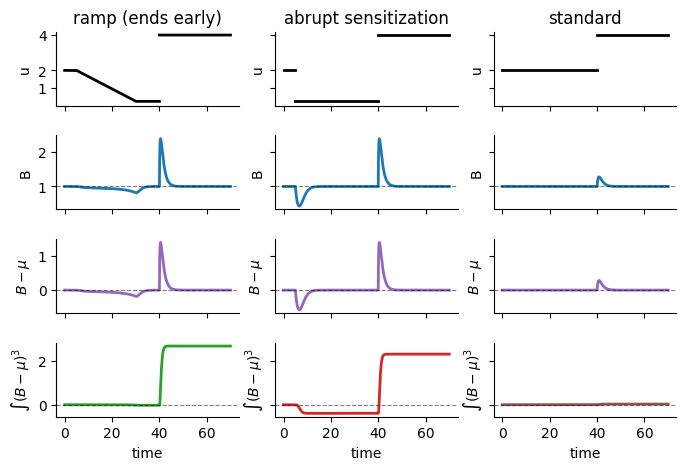

Figure saved to /Users/jonathansomer/repos/autodiff-control/plots/figure5_case_4_three_protocols.pdf


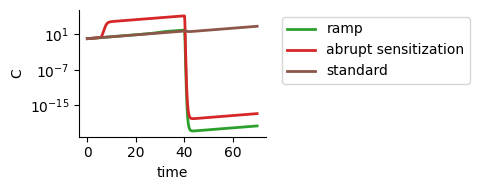

Figure saved to /Users/jonathansomer/repos/autodiff-control/plots/figure5_case_4_three_protocols_C.pdf
final integral (ramp):       -53.417
final integral (sensitized): -46.051
final integral (standard):   -0.577


In [186]:
# 3-protocol comparison: ramp, abrupt sensitization, standard
t1, t2, t_end = 5.0, 40.0, 70.0
t_ramp_end = t2 - 10.0
c1, c2, mu = 0.1, 20, 1
C0 = 1.0
A0, B0 = 2.0, 1.0
sensitization_u = 0.25


def integrate_C_cubic(t, B):
    def f(tt, C):
        B_t = np.interp(tt, t, B)
        return C[0] * (c1 - c2 * (B_t - mu) ** 3)
        # return C[0] * (c1 - c2 * (B_t - mu))
    sol = solve_ivp(f, [t[0], t[-1]], [C0], t_eval=t,
                    max_step=0.05, rtol=1e-8, atol=1e-10)
    return sol.y[0]


# ── Inputs ──────────────────────────────────────────────────────────
def u_of_t_ramp(tt):
    if tt < t1: return 2.0
    if tt < t_ramp_end: return 2.0 + (sensitization_u - 2.0) * (tt - t1) / (t_ramp_end - t1)
    if tt < t2: return sensitization_u
    return 4.0

def u_of_t_sensitized(tt):
    if tt < t1: return 2.0
    if tt < t2: return sensitization_u
    return 4.0

def u_of_t_standard(tt):
    # no sensitization: hold at 2 until t2, then jump to 4
    if tt < t2: return 2.0
    return 4.0


t = np.linspace(0, t_end, 6000)


def simulate(u_fn):
    sol = solve_ivp(fcd_rhs, [0, t_end], [A0, B0], t_eval=t,
                    args=(u_fn,), max_step=0.05,
                    rtol=1e-8, atol=1e-10)
    B = sol.y[1]
    C = integrate_C_cubic(t, B)
    return B, C


B_ramp,        C_ramp        = simulate(u_of_t_ramp)
B_sensitized,  C_sensitized  = simulate(u_of_t_sensitized)
B_standard,    C_standard    = simulate(u_of_t_standard)

from scipy.integrate import cumulative_trapezoid
I_ramp       = cumulative_trapezoid((B_ramp       - mu) ** 3, t, initial=0.0)
I_sensitized = cumulative_trapezoid((B_sensitized - mu) ** 3, t, initial=0.0)
I_standard   = cumulative_trapezoid((B_standard   - mu) ** 3, t, initial=0.0)


# ── Top figure: u, B, B-mu, integral over 3 protocols (4 rows × 3 cols) ──
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(8, 5),
                         sharex=True, sharey='row',
                         gridspec_kw={'hspace': 0.4})

lw = 2

protocols = [
    ('ramp (ends early)',      u_of_t_ramp,        B_ramp,       I_ramp,       [(0, t_end)]),
    ('abrupt sensitization',   u_of_t_sensitized,  B_sensitized, I_sensitized, [(0, t1), (t1, t2), (t2, t_end)]),
    ('standard',               u_of_t_standard,    B_standard,   I_standard,   [(0, t2), (t2, t_end)]),
]

for col, (title, u_fn, B_vec, I_vec, segments) in enumerate(protocols):
    # Row 0: u
    ax = axes[0, col]
    if title.startswith('ramp'):
        u_vals = np.array([u_fn(tt) for tt in t])
        u_plot = u_vals.copy()
        u_plot[np.isclose(t, t2, atol=t[1] - t[0])] = np.nan
        ax.plot(t, u_plot, lw=lw, color='k')
    else:
        for seg in segments:
            ax.plot(seg,
                    [u_fn(seg[0] + 0.01), u_fn(seg[1] - 0.01)],
                    lw=lw, color='k')
    ax.set_ylabel('u')
    ax.set_yticks([1, 2, 4])
    ax.set_ylim(bottom=0)
    ax.set_title(title)

    # Row 1: B
    axes[1, col].plot(t, B_vec, lw=lw, color='C0')
    axes[1, col].axhline(mu, color='k', linestyle='--', lw=0.8, alpha=0.5)
    axes[1, col].set_ylabel('B')

    # Row 2: B - mu
    axes[2, col].plot(t, B_vec - mu, lw=lw, color='C4')
    axes[2, col].axhline(0, color='k', linestyle='--', lw=0.8, alpha=0.5)
    axes[2, col].set_ylabel(r'$B - \mu$')

    # Row 3: cumulative integral of (B-mu)^3
    axes[3, col].plot(t, I_vec, lw=lw, color=['C2', 'C3', 'C5'][col])
    axes[3, col].axhline(0, color='k', linestyle='--', lw=0.8, alpha=0.5)
    axes[3, col].set_ylabel(r'$\int (B-\mu)^3$')
    axes[3, col].set_xlabel('time')

for ax in axes.flatten():
    sns.despine(ax=ax)

plt.show()
save_fig(fig, 'figure5_case_4_three_protocols.pdf')


# ── Bottom figure: all 3 cancer trajectories overlaid ───────────────
fig_C, ax = plt.subplots(figsize=(5, 2))
ax.plot(t, C_ramp,       lw=lw, color='C2', label='ramp')
ax.plot(t, C_sensitized, lw=lw, color='C3', label='abrupt sensitization')
ax.plot(t, C_standard,   lw=lw, color='C5', label='standard')
ax.set_xlabel('time')
ax.set_ylabel('C')
ax.set_yscale('log')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()
save_fig(fig_C, 'figure5_case_4_three_protocols_C.pdf')

print(f"final integral (ramp):       {-c2 * I_ramp[-1]:.3f}")
print(f"final integral (sensitized): {-c2 * I_sensitized[-1]:.3f}")
print(f"final integral (standard):   {-c2 * I_standard[-1]:.3f}")


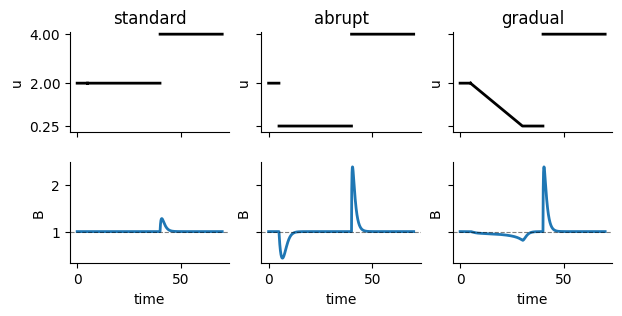

Figure saved to /Users/jonathansomer/repos/autodiff-control/plots/figure5_three_strategies_uB.pdf


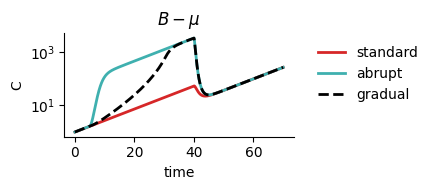

Figure saved to /Users/jonathansomer/repos/autodiff-control/plots/figure5_three_strategies_C_kernel_B-mu.pdf


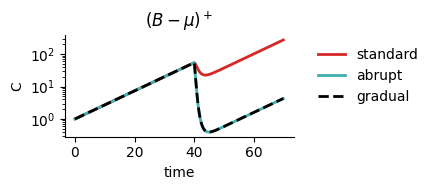

Figure saved to /Users/jonathansomer/repos/autodiff-control/plots/figure5_three_strategies_C_kernel_B-muplus.pdf


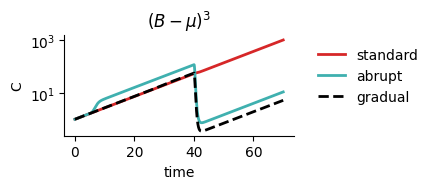

Figure saved to /Users/jonathansomer/repos/autodiff-control/plots/figure5_three_strategies_C_kernel_B-mu3.pdf


In [204]:
# Three strategies × three killing kernels
t1, t2, t_end = 5.0, 40.0, 70.0
t_ramp_end = t2 - 10.0
c1, c2, mu = 0.1, 2, 1
C0 = 1.0
A0, B0 = 2.0, 1.0
sensitization_u = 0.25


def make_integrate_C(kernel):
    def integrate(t, B):
        def f(tt, C):
            B_t = np.interp(tt, t, B)
            return C[0] * (c1 - c2 * kernel(B_t - mu))
        sol = solve_ivp(f, [t[0], t[-1]], [C0], t_eval=t,
                        max_step=0.05, rtol=1e-8, atol=1e-10)
        return sol.y[0]
    return integrate


kernels = [
    (r'$B - \mu$',           lambda x: x),
    (r'$(B - \mu)^+$',       lambda x: max(x, 0.0)),
    (r'$(B - \mu)^3$',       lambda x: x ** 3),
]


def u_standard(tt):
    if tt < t2: return 2.0
    return 4.0

def u_abrupt(tt):
    if tt < t1: return 2.0
    if tt < t2: return sensitization_u
    return 4.0

def u_gradual(tt):
    if tt < t1: return 2.0
    if tt < t_ramp_end:
        return 2.0 + (sensitization_u - 2.0) * (tt - t1) / (t_ramp_end - t1)
    if tt < t2: return sensitization_u
    return 4.0


strategies = [
    ('standard', u_standard, 'C3'),
    ('abrupt',   u_abrupt,   '#3FB0AF'),
    ('gradual',  u_gradual,  'k'),
]

t = np.linspace(0, t_end, 6000)

# Simulate B once per strategy (kernel only affects C)
strategy_data = {}
for name, u_fn, color in strategies:
    sol = solve_ivp(fcd_rhs, [0, t_end], [A0, B0], t_eval=t,
                    args=(u_fn,), max_step=0.05,
                    rtol=1e-8, atol=1e-10)
    B = sol.y[1]
    u_vals = np.array([u_fn(tt) for tt in t])
    strategy_data[name] = dict(u=u_vals, B=B, color=color)


# ── Top figure: 2 rows × 3 cols (u, B) ──────────────────────────────
lw = 2
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(7, 3),
                         sharex=True, sharey='row',
                         gridspec_kw={'hspace': 0.3})

for col, (name, _, _) in enumerate(strategies):
    r = strategy_data[name]
    u_plot = r['u'].astype(float).copy()
    for t_jump in [t1, t2]:
        u_plot[np.isclose(t, t_jump, atol=t[1] - t[0])] = np.nan

    axes[0, col].plot(t, u_plot, lw=lw, color='k')
    axes[0, col].set_ylabel('u')
    axes[0, col].set_yticks([sensitization_u, 2, 4])
    axes[0, col].set_ylim(bottom=0)
    axes[0, col].set_title(name)

    axes[1, col].plot(t, r['B'], lw=lw, color='C0')
    axes[1, col].axhline(mu, color='k', linestyle='--', lw=0.8, alpha=0.5)
    axes[1, col].set_ylabel('B')
    axes[1, col].set_xlabel('time')

for ax in axes.flatten():
    sns.despine(ax=ax)

plt.show()
save_fig(fig, 'figure5_three_strategies_uB.pdf')


# ── Loop over kernels: one C plot per kernel ────────────────────────
for kernel_label, kernel_fn in kernels:
    integrate_C = make_integrate_C(kernel_fn)

    fig_C, ax = plt.subplots(figsize=(4.5, 2))
    for name, _, _ in strategies:
        r = strategy_data[name]
        C = integrate_C(t, r['B'])
        linestyle = '--' if name == 'gradual' else '-'
        ax.plot(t, C, lw=lw, color=r['color'], label=name, linestyle=linestyle)

    ax.set_xlabel('time')
    ax.set_ylabel('C')
    ax.set_yscale('log')
    ax.set_title(f'{kernel_label}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

    safe = kernel_label.replace('$', '').replace('\\', '').replace(' ', '').replace('^', '').replace('(', '').replace(')', '').replace('+', 'plus')
    save_fig(fig_C, f'figure5_three_strategies_C_kernel_{safe}.pdf')
